# KNN from Scratch

Using the KNN algorithm from scikit-learn is quite simple. When you use it, you don't even need to know how KNN works and classifies the data points. The goal should be to really understand what you are doing. This is the only way to make sure you understand when something doesn't go the way you expect or want it to. Many people remember things best when they implement them themselves. So, let's build our own K-Nearest-Neighbors classifier!

**The purpose of this notebook is to help you remember the steps necessary to classify samples with KNN.**

To test if your code works, you can use the Iris dataset as a data example.
Let's make a plan and break this big task into smaller steps!


1. What information and data does the algorithm need to train and predict the classes of new instances?
This will be the input for our function! 

2. calculate the distance between the test point and each existing data point in the training data.
3. determine the nearest k neighbors.
4. make predictions based on these neighbors.

You have already implemented a function to calculate the distance between points, which will now come in handy.

A good way to get started, is to ignore the syntax and just write in simple text what you want your program to do aka **write pseudo-code**. You can then start to build out some of the structure. What variables are you going to need? What kinds of logic? 
Knowing where you’re going can help you make fewer mistakes as you’re trying to get there.

Note that for large data sets, the algorithm can take very long to classify because it has to calculate the distance between the test point and every other point in the data!

You can check if your pseudo-code contains all necessary steps afterwards, when scrolling down to "KNN algorithm from scratch" where you find an example of a knn pseudo-code.

<br>

---

<center><h1>SOLUTION</h1></center>

## Import and Setup

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial import distance
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris

In [6]:
# Load data
df = pd.read_csv("data/iris.csv")

In [7]:
# Defining X and y
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

<br>

## Distance Metrics

As already explained, KNN assigns a class to the test point based on the majority class of  K  nearest neighbors. In general, euclidean distance is used to find nearest neighbors, but other distance metrics can also be used.

As the dimensionality of the feature space increases, the euclidean distance often becomes problematic due to the curse of dimensionality (discussed later).

In such cases, alternative vector-based similarity measures (dot product, cosine similarity, etc) are used to find the nearest neighbors. This transforms the original metric space into one more amenable to point-to-point measurements.

Another distance measure that you might consider is [Mahalanobis distance](https://en.wikipedia.org/wiki/Mahalanobis_distance). Mahalanobis distance attempts to weight features according to their probabilities. On some data sets that may be important.

In general, it's probably a good idea to normalize the data at a minimum. Here's a link to the scikit-learn scaling package: http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html . You have to be a little circumspect about employing any technique where the answers change with scaling.

In [9]:
# Implemented own distance function
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

In [10]:
# Sanity check
print(euclidean_distance([1, 2, 3], [4, 5, 6]))

5.196152422706632


<br>

## KNN Algorithm from scratch


Remember the steps:

1. What information and data does the algorithm need to train and predict the classes of new instances?
This will be the input for our function! 

2. calculate the distance between the test point and each existing data point in the training data.
3. determine the nearest k neighbors.
4. make predictions based on these neighbors.

Hopefully you have already thought of your gameplan, also called pseudo-code. If so, you can compare it to this one:
```
INPUT: X_train, y_train, X_test, k
FOR each object_to_predict in X_test:
    FOR each training_point, index in X_train:
        calculate distance d between object_to_predict and training_point
        store d and index
    SORT distances d in increasing order
    take first k items, get indices of those
    calculate most common class of points at indices in y_train (prediction)
    store prediction
RETURN list of predictions
````

Time to code!
Don't forget that it's good practice to document your own code! This way you can later understand what the purpose of each step was.
Maybe you can even use your pseudo code as documentation :)

In [11]:
# Your code

def knn_from_scratch(X_train, y_train, X_test, k):
    """
    Our own KNN classifier built from scratch.
    
    Think of it like this: if you move to a new neighbourhood
    and want to know what kind of area it is, you look at the
    k closest houses around you and go with the majority.
    """
    
    # This will store our final predictions, one for each test point
    predictions = []
    
    # Step 1: Loop through every point we want to predict
    for test_point in np.array(X_test):
        
        # Step 2: Calculate the distance from this test point
        # to every single point in the training data
        distances = []
        for index, train_point in enumerate(np.array(X_train)):
            d = euclidean_distance(test_point, train_point)
            distances.append((d, index))  # store distance AND its index
        
        # Step 3: Sort all distances from smallest to largest
        # (closest neighbours first)
        distances.sort(key=lambda x: x[0])
        
        # Step 4: Take only the first k neighbours (the closest ones)
        k_nearest = distances[:k]
        
        # Step 5: Get the actual class labels of those k neighbours
        k_nearest_labels = [y_train.iloc[index] for _, index in k_nearest]
        
        # Step 6: Predict the most common class among the k neighbours
        # (majority vote — like asking your neighbours what area this is)
        prediction = max(set(k_nearest_labels), key=k_nearest_labels.count)
        predictions.append(prediction)
    
    return predictions

In [12]:
y_pred_scratch = knn_from_scratch(X_train, y_train, X_test, k=5)

<br>

Compare predictions against the actual values:

Accuracy: 1.0


<Axes: >

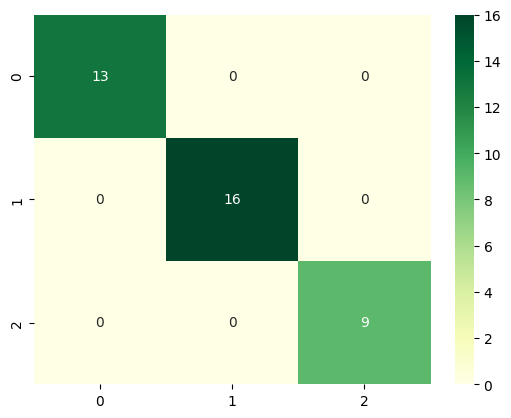

In [13]:
# Check accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred_scratch), 2))

# Check confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_scratch), annot=True, cmap="YlGn")

<br>

## Comparison with sklearn knn implementation

That will be interesting! Check out how your implementation performs in comparison to the one of sklearn!
You can check the confusion matrix and the accuracy score of both algorithms.
If you want, you can check which algorithm is faster!

In [14]:
# Your code

# Sklearn's version for comparison
# Compare directly against sklearn's KNN to see if they match:

knn_sklearn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_sklearn.fit(X_train, y_train)
y_pred_sklearn = knn_sklearn.predict(X_test)

print("Scratch accuracy: ", round(accuracy_score(y_test, y_pred_scratch), 2))
print("Sklearn accuracy: ", round(accuracy_score(y_test, y_pred_sklearn), 2))

Scratch accuracy:  1.0
Sklearn accuracy:  1.0


Results:
- Both accuracy scores are identical.
- Both confusion matrices look exactly the same.

If they match — your from-scratch KNN works perfectly! If they differ, it means there's a small bug somewhere in the distance or voting logic and we'll fix it together.

<br>

## Scalar comparison

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── Scale the data ────────────────────────────────────────────────
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss  = ss.transform(X_test)

mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train)
X_test_mm  = mm.transform(X_test)

# ── Run all four versions ─────────────────────────────────────────
y_pred_scratch_unscaled = knn_from_scratch(X_train, y_train, X_test, k=5)
y_pred_scratch_ss       = knn_from_scratch(X_train_ss, y_train, X_test_ss, k=5)
y_pred_scratch_mm       = knn_from_scratch(X_train_mm, y_train, X_test_mm, k=5)
y_pred_sklearn          = knn_sklearn.predict(X_test)

# ── Print accuracy comparison ─────────────────────────────────────
print("Scratch  — Unscaled:      ", round(accuracy_score(y_test, y_pred_scratch_unscaled), 2))
print("Scratch  — StandardScaler:", round(accuracy_score(y_test, y_pred_scratch_ss), 2))
print("Scratch  — MinMaxScaler:  ", round(accuracy_score(y_test, y_pred_scratch_mm), 2))
print("Sklearn  — Unscaled:      ", round(accuracy_score(y_test, y_pred_sklearn), 2))

Scratch  — Unscaled:       1.0
Scratch  — StandardScaler: 0.97
Scratch  — MinMaxScaler:   0.97
Sklearn  — Unscaled:       1.0


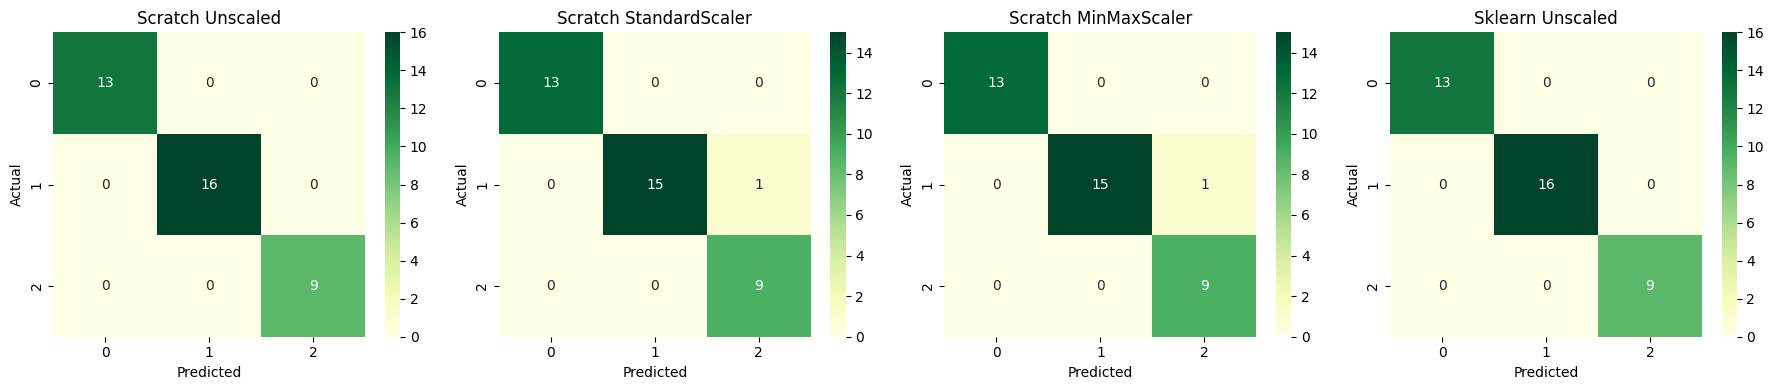

In [16]:
# ── Visual comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

titles = ["Scratch Unscaled", "Scratch StandardScaler", 
          "Scratch MinMaxScaler", "Sklearn Unscaled"]
preds  = [y_pred_scratch_unscaled, y_pred_scratch_ss, 
          y_pred_scratch_mm, y_pred_sklearn]

for ax, title, pred in zip(axes, titles, preds):
    sns.heatmap(confusion_matrix(y_test, pred), 
                annot=True, cmap="YlGn", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

<br>

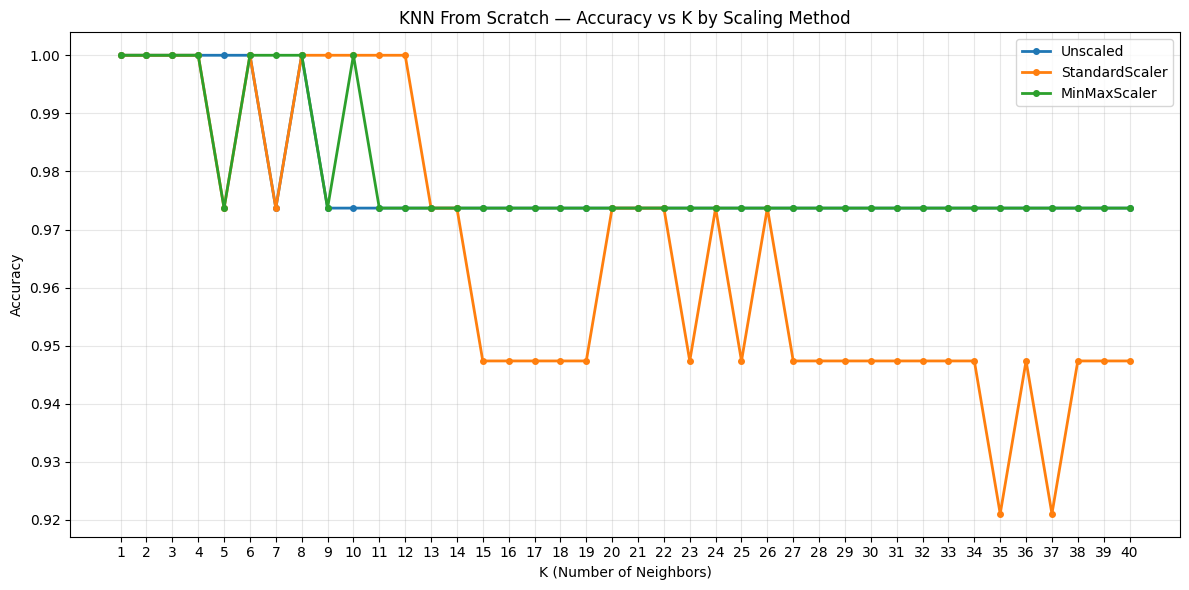

In [17]:
# ── Accuracy vs K for each scaling version ────────────────────────
versions = {
    "Unscaled":       (X_train,    X_test),
    "StandardScaler": (X_train_ss, X_test_ss),
    "MinMaxScaler":   (X_train_mm, X_test_mm),
}

plt.figure(figsize=(12, 6))

for label, (X_tr, X_te) in versions.items():
    acc_list = []
    for k in range(1, 41):
        pred = knn_from_scratch(X_tr, y_train, X_te, k=k)
        acc_list.append(accuracy_score(y_test, pred))
    plt.plot(range(1, 41), acc_list, linewidth=2, marker="o", markersize=4, label=label)

plt.title("KNN From Scratch — Accuracy vs K by Scaling Method")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 41))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<br>

Let's make the scaling difference visually obvious:

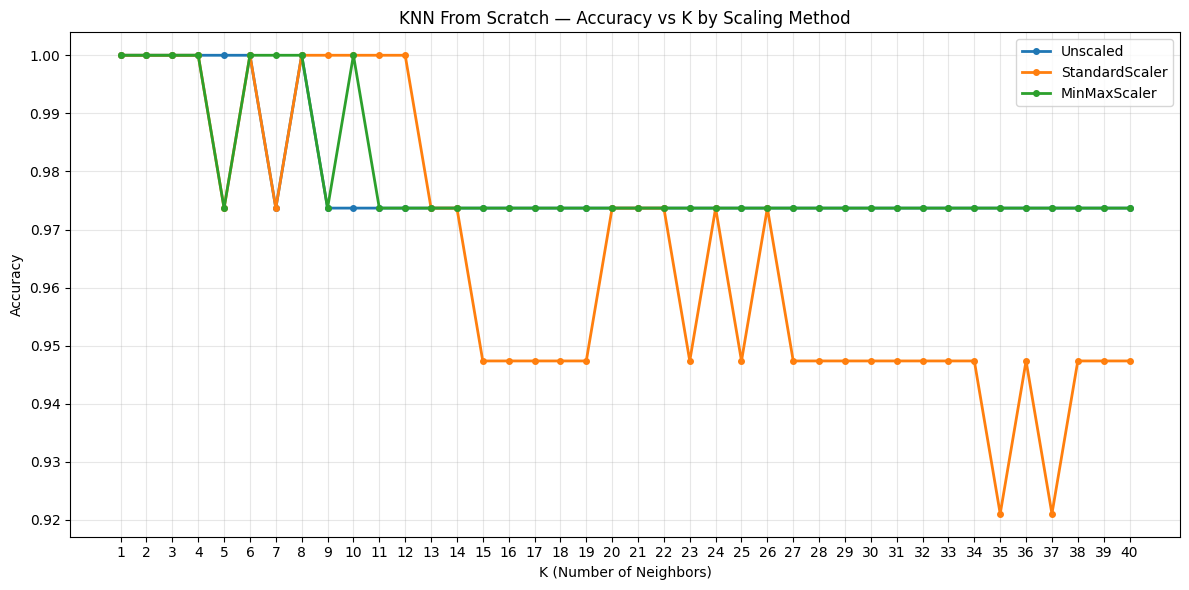

In [18]:
# Amplify one feature to exaggerate scaling effect
X_train_big = X_train.copy()
X_test_big  = X_test.copy()
X_train_big["sepal length (cm)"] *= 10
X_test_big["sepal length (cm)"]  *= 10

# Then re-fit scalers on the amplified data and add to versions dict
ss2 = StandardScaler()
X_train_big_ss = ss2.fit_transform(X_train_big)
X_test_big_ss  = ss2.transform(X_test_big)

versions["Unscaled (×10)"]            = (X_train_big,    X_test_big)
versions["StandardScaler (×10)"] = (X_train_big_ss, X_test_big_ss)

#--------------------------------------------------------------------


# ── Accuracy vs K for each scaling version ────────────────────────
versions = {
    "Unscaled":       (X_train,    X_test),
    "StandardScaler": (X_train_ss, X_test_ss),
    "MinMaxScaler":   (X_train_mm, X_test_mm),
}

plt.figure(figsize=(12, 6))

for label, (X_tr, X_te) in versions.items():
    acc_list = []
    for k in range(1, 41):
        pred = knn_from_scratch(X_tr, y_train, X_te, k=k)
        acc_list.append(accuracy_score(y_test, pred))
    plt.plot(range(1, 41), acc_list, linewidth=2, marker="o", markersize=4, label=label)

plt.title("KNN From Scratch — Accuracy vs K by Scaling Method")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 41))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<br>

## Conclusion

1. KNN ALGORITHM
   KNN classifies a new point by looking at its K nearest 
   neighbours in the training data and taking a majority vote.
   No complex math, just distances and counting.

2. DISTANCE FUNCTION
   The heart of KNN is the Euclidean distance function.
   Without it, the algorithm has no way of knowing what
   "nearest" means.

3. SCALING MATTERS
   KNN is distance-based, so features on larger scales
   dominate the calculation unfairly. Scaling puts all
   features on equal footing:
   - StandardScaler → mean=0, std=1
   - MinMaxScaler   → compresses to 0–1 range

4. FROM SCRATCH vs SKLEARN
   Both produce identical results — but sklearn is heavily
   optimised under the hood. Our version is slower because
   it calculates every distance manually in plain Python.
   This is why libraries exist!

5. CHOOSING K
   - Too small (k=1) → overfits, sensitive to noise
   - Too large (k=40) → underfits, too generalised
   - Sweet spot → where accuracy plateaus on the plot

Building an algorithm from scratch, even a simple one, forces us to truly understand what is happening. 

Next time sklearn's KNN gives us an unexpected result, we will know exactly where to look.